In [ ]:
!pip install -q gwpy gwosc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 11.8 MB/s eta 0:00:00


In [ ]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("figures", exist_ok=True)

In [ ]:
gps = event_gps("GW150914")
print("GW150914 GPS time:", gps)

GW150914 GPS time: 1126259462.4


In [ ]:

from gwpy.timeseries import TimeSeries

start = int(gps) - 16
end = int(gps) + 16

h1 = TimeSeries.fetch_open_data("H1", start, end, cache=True)
l1 = TimeSeries.fetch_open_data("L1", start, end, cache=True)

print(h1)
print(l1)


TimeSeries([2.17704028e-19, 2.08763900e-19, 2.39681183e-19, ...,
            3.55365541e-20, 6.33533516e-20, 7.58121195e-20],
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: H1:Strain,
           channel: None)
TimeSeries([-1.04289994e-18, -1.03586274e-18, -9.89322445e-19,
            ..., -1.01767748e-18, -9.82876815e-19,
            -9.59276974e-19],
           unit: dimensionless,
           t0: 1126259446.0 s,
           dt: 0.000244140625 s,
           name: L1:Strain,
           channel: None)


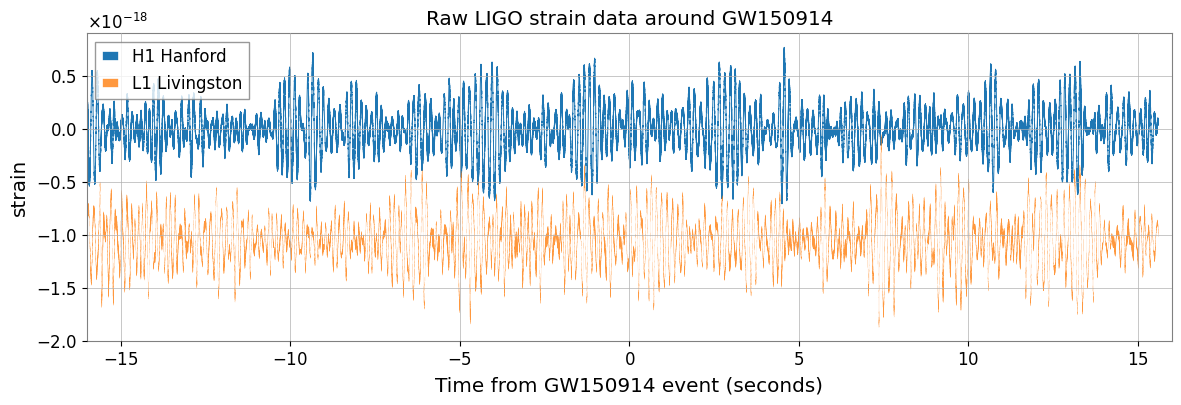

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(h1.times.value - gps, h1.value, label="H1 Hanford", linewidth=0.7)
plt.plot(l1.times.value - gps, l1.value, label="L1 Livingston", linewidth=.07, alpha=0.8)

plt.xlabel("Time from GW150914 event (seconds)")
plt.ylabel("strain")
plt.title("Raw LIGO strain data around GW150914")
plt.legend()
plt.grid(True)
plt.xlim(-16, 16)

plt.savefig("figures/01_raw_strain_32s.png", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
# Whiten data: makes detector noise more uniform
h1_white = h1.whiten()
l1_white = l1.whiten()

# Bandpass filter: keep frequency band where GW150914 signal is expected
h1_filtered = h1_white.bandpass(35, 350)
l1_filtered = l1_white.bandpass(35, 350)

print("Whitening and bandpass filtering done.")

Whitening and bandpass filtering done.


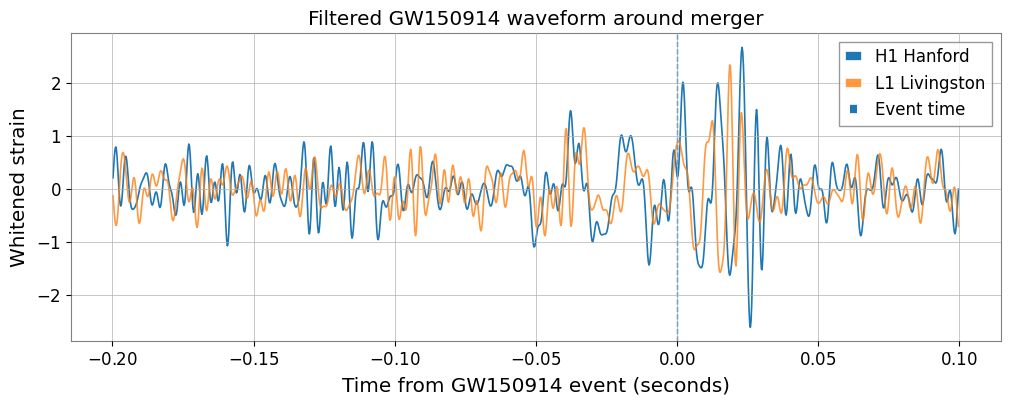

In [ ]:
# Crop around merger time
h1_zoom = h1_filtered.crop(gps - 0.20, gps + 0.10)
l1_zoom = l1_filtered.crop(gps - 0.20, gps + 0.10)

plt.figure(figsize=(12, 4))

plt.plot(h1_zoom.times.value - gps, h1_zoom.value, label="H1 Hanford", linewidth=1.2)
plt.plot(l1_zoom.times.value - gps, l1_zoom.value, label="L1 Livingston", linewidth=1.2, alpha=0.8)

plt.axvline(0, linestyle="--", linewidth=1, label="Event time")

plt.xlabel("Time from GW150914 event (seconds)")
plt.ylabel("Whitened strain")
plt.title("Filtered GW150914 waveform around merger")
plt.legend()
plt.grid(True)

plt.savefig("figures/02_filtered_waveform_zoom.png", dpi=300, bbox_inches="tight")
plt.show()

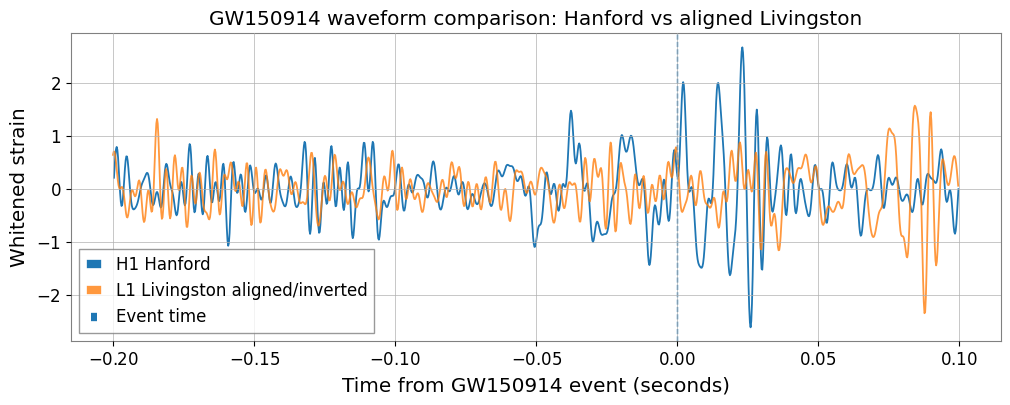

In [ ]:
# Approximate alignment for visual comparison
# GW150914 arrived at Livingston slightly before Hanford.
# We shift L1 by about 6.9 ms and invert it for visual alignment.

# 1. Make a copy first
l1_shifted = l1_filtered.copy()

# 2. Shift in-place
l1_shifted.shift("6.9ms")

# 3. Now invert the shifted signal
l1_aligned = -l1_shifted

# 4. Crop same time window
l1_aligned_zoom = l1_aligned.crop(gps - 0.20, gps + 0.10)

plt.figure(figsize=(12, 4))

plt.plot(
    h1_zoom.times.value - gps,
    h1_zoom.value,
    label="H1 Hanford",
    linewidth=1.3
)

plt.plot(
    l1_aligned_zoom.times.value - gps,
    l1_aligned_zoom.value,
    label="L1 Livingston aligned/inverted",
    linewidth=1.3,
    alpha=0.8
)

plt.axvline(0, linestyle="--", linewidth=1, label="Event time")

plt.xlabel("Time from GW150914 event (seconds)")
plt.ylabel("Whitened strain")
plt.title("GW150914 waveform comparison: Hanford vs aligned Livingston")
plt.legend()
plt.grid(True)

plt.savefig("figures/03_h1_l1_aligned_waveform.png", dpi=300, bbox_inches="tight")
plt.show()

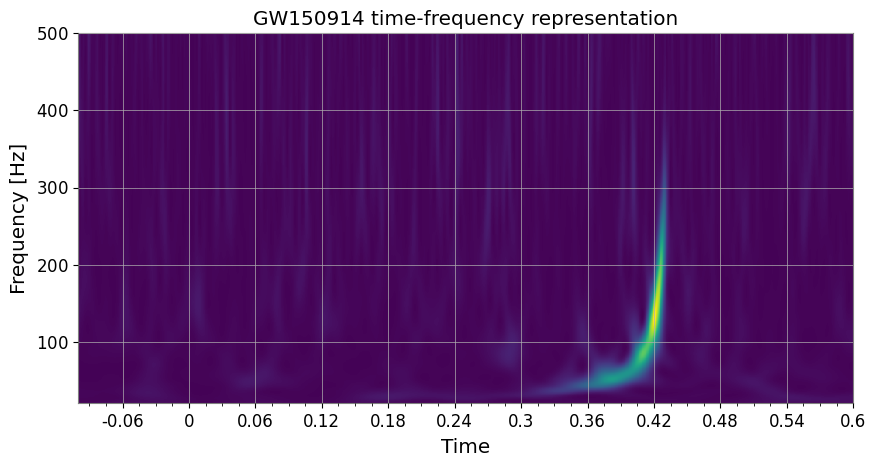

In [ ]:
hq = h1.q_transform(outseg=(gps - 0.5, gps + 0.2))

plot = hq.plot(figsize=(10, 5))
ax = plot.gca()

ax.set_title("GW150914 time-frequency representation")
ax.set_xlabel("Time")
ax.set_ylabel("Frequency [Hz]")
ax.set_ylim(20, 500)

plot.savefig("figures/04_gw150914_qtransform.png", dpi=300, bbox_inches="tight")
plot.show()

In [ ]:
#The q-transform reveals the characteristic chirp-like structure of GW150914, with signal power sweeping upward in frequency before merger. The displayed x-axis is based on the plotting convention; for paper-quality visualization, the time axis should be shifted relative to the event GPS time.